## SNOTEL QC Development
Evaluate some approaches to doing QC on SNOTEL data.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time
from buildforcing.datasets import PNNLSnotel

In [2]:
site = 'Baldy'

### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [3]:
snotel = PNNLSnotel(site_name=site, storage_path='C:/Users/clmbn/NMT_PhD/data/snotel/')
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 33.98, Longitude: -109.5


In [4]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1988-09-27 to 2021-09-30


In [5]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

I think most of the datasets are daily with Nans for missing data, but it seems reasonable to ensure that is the case.

In [6]:
# Ensure index is daily
snotel_data = snotel_data.asfreq('D')

#### Visualization

In [7]:
# Calculate F temperatures for easier analysis
snotel_data['T_max_F'] = snotel_data['T_max_C'] * 9/5 + 32
snotel_data['T_min_F'] = snotel_data['T_min_C'] * 9/5 + 32
snotel_data['T_avg_F'] = snotel_data['T_avg_C'] * 9/5 + 32

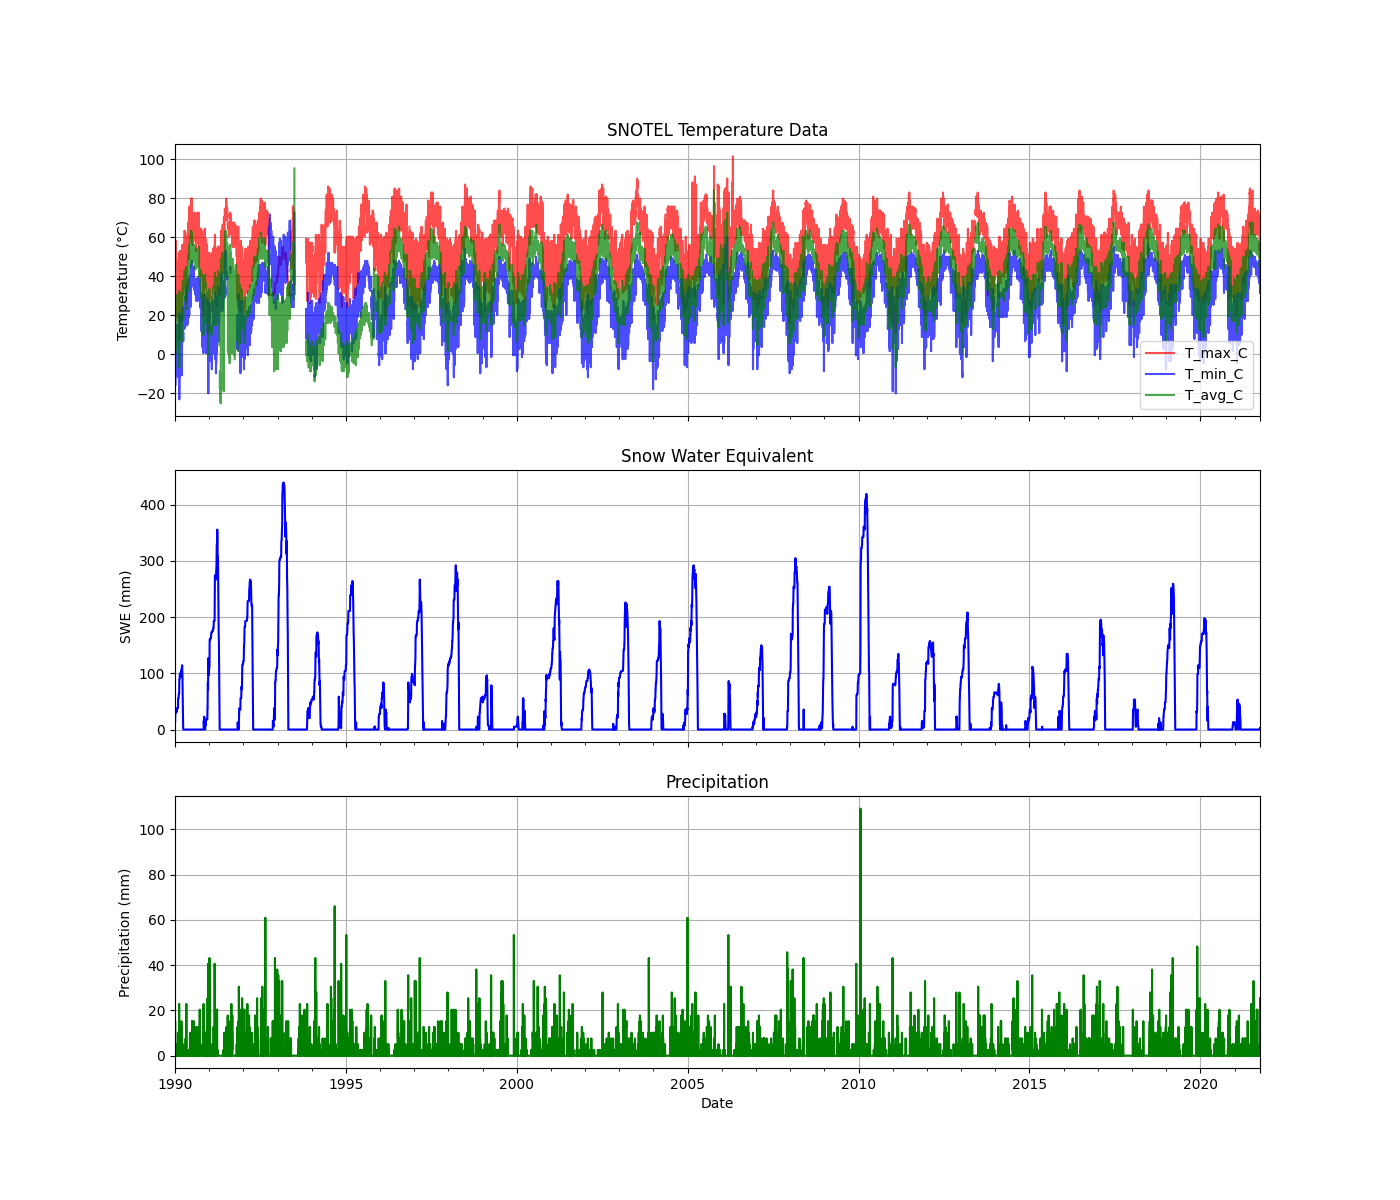

In [8]:
# Create a single figure with 3 subplots (temperature, SWE, precipitation)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot temperatures in the top subplot
snotel_data['T_max_F'].plot(ax=ax1, label='T_max_C', color='red', alpha=0.7)
snotel_data['T_min_F'].plot(ax=ax1, label='T_min_C', color='blue', alpha=0.7)
snotel_data['T_avg_F'].plot(ax=ax1, label='T_avg_C', color='green', alpha=0.7)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('SNOTEL Temperature Data')
ax1.legend()
ax1.grid(True)

# Plot SWE in the middle subplot
ax2.plot(snotel_data.index, snotel_data['swe_mm'], color='blue')
ax2.set_ylabel('SWE (mm)')
ax2.set_title('Snow Water Equivalent')
ax2.grid(True)

# Plot Precipitation in the bottom subplot
ax3.plot(snotel_data.index, snotel_data['precip_mm'], color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('Precipitation (mm)')
ax3.set_title('Precipitation')
ax3.grid(True)

plt.show()

Extract sections of interest for manual review.

In [9]:
review_section = snotel_data.loc['1992-10-01':'1993-07-01', ['T_max_C', 'T_min_C', 'T_avg_C']]
test_section = snotel_data.loc['1992-01-01':'1994-07-01', ['T_max_C', 'T_min_C', 'T_avg_C']]

### QC approaches
I'll start by flagging values, then decide if I want to remove them or fill them later.

In [10]:
# I can't use days with only a max or a min. Set those to NaN for now.
test_section.loc[test_section['T_max_C'].isna() | test_section['T_min_C'].isna(), ['T_max_C', 'T_min_C', 'T_avg_C']] = np.nan

#### Check 1.
Ensure consistency between temperature variables (T_max, T_min, T_avg).
- T_max should always be >= T_min
- T_avg should always be between T_max and T_min
- Diurnal temperature range (T_max - T_min) should be reasonable. At the least, I think it should be > 5 degrees C. 

In [33]:
test_section['bad_max_min'] = (test_section['T_max_C'] - test_section['T_min_C']) < 5
#test_section['avg_not_between'] = ~test_section['T_avg_C'].between(test_section['T_min_C'], test_section['T_max_C'])

I have found data where the average is clearly bad, but the the max and min are reasonable. If I don't know if the average is good, I can't use it because it will create false flags.

In [34]:
#test_section['flagged'] = test_section['bad_max_min'] | test_section['avg_not_between']
test_section['flagged'] = test_section['bad_max_min']

In [35]:
test_clean = test_section[test_section['flagged'] == False]

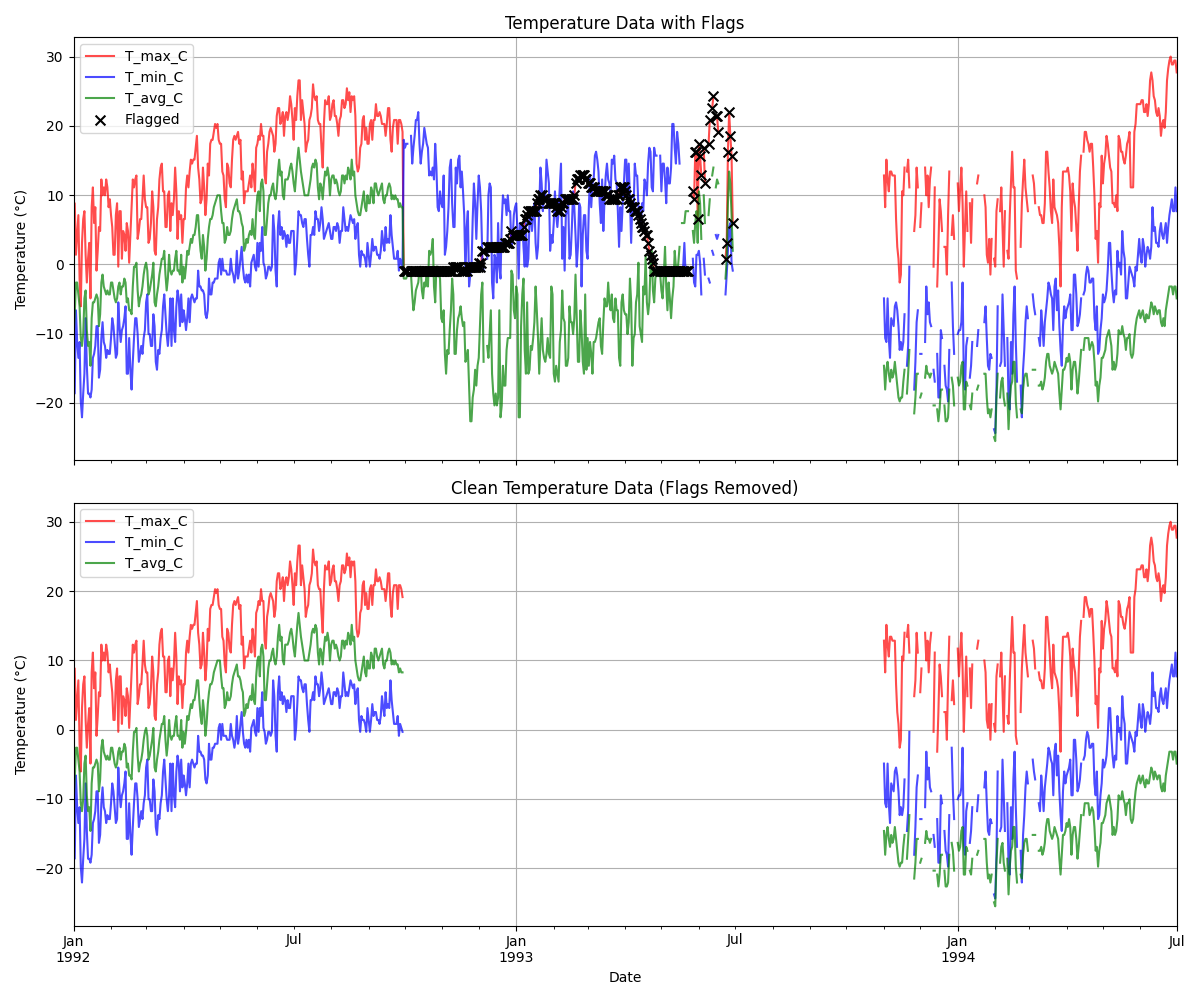

In [38]:
# Plot test section with flags and clean data in two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot test section with flags in the top subplot
test_section['T_max_C'].plot(ax=ax1, label='T_max_C', color='red', alpha=0.7)
test_section['T_min_C'].plot(ax=ax1, label='T_min_C', color='blue', alpha=0.7)
test_section['T_avg_C'].plot(ax=ax1, label='T_avg_C', color='green', alpha=0.7)
ax1.scatter(test_section.index[test_section['flagged']], test_section['T_max_C'][test_section['flagged']], 
           color='black', marker='x', s=50, label='Flagged', zorder=5)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature Data with Flags')
ax1.legend()
ax1.grid(True)

# Plot clean data in the bottom subplot
test_clean['T_max_C'].plot(ax=ax2, label='T_max_C', color='red', alpha=0.7)
test_clean['T_min_C'].plot(ax=ax2, label='T_min_C', color='blue', alpha=0.7)
test_clean['T_avg_C'].plot(ax=ax2, label='T_avg_C', color='green', alpha=0.7)
ax2.set_ylabel('Temperature (°C)')
ax2.set_xlabel('Date')
ax2.set_title('Clean Temperature Data (Flags Removed)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

In [37]:
# Baldy specific for testing...
# Flag all data between Dec 1992 and Aug 1993 as bad
test_section.loc['1992-12-01':'1993-08-01', 'flagged'] = True
test_clean = test_section[test_section['flagged'] == False]

## Gap Filling
Explore filling gaps in data with NLDAS

In [13]:
from buildforcing.datasets import siteNLDAS
import os

For this investigation, I will just load a subset of the NLDAS data so that I can assess methods.

In [12]:
# start_dt = datetime.combine(start_date, time(0, 0))
# end_dt = datetime.combine(end_date, time(23, 0))
start_dt = datetime(1992, 1, 1, 0, 0)
end_dt = datetime(1995, 12, 31, 23, 0)
nldas = siteNLDAS(snotel.latitude, snotel.longitude, start_date=start_dt, end_date=end_dt)

In [14]:
nldas.loadNetCDF(os.environ['NLDAS_PATH'])

In [15]:
nldas.data.head()

,LWdown,PSurf,Qair,Rainf,SWdown,Tair,Wind_E,Wind_N
Date&Time,,,,,,,,
1992-01-01 00:00:00+00:00,168.38,72744.6,0.002453,0.0,18.976,267.39,2.80,0.22
1992-01-01 01:00:00+00:00,168.37,72707.2,0.002274,0.0,0.000,266.74,2.02,-1.08
1992-01-01 02:00:00+00:00,168.35,72669.8,0.002095,0.0,0.000,266.09,1.24,-2.38
1992-01-01 03:00:00+00:00,168.57,72633.1,0.001916,0.0,0.000,265.44,0.46,-3.68
1992-01-01 04:00:00+00:00,168.56,72704.2,0.001913,0.0,0.000,265.32,0.72,-3.24


Initial evaluation of simply filling gaps with NLDAS

In [40]:
# Calculate daily max and min temperatures from hourly NLDAS data
nldas_daily = nldas.data.resample('D').agg({'Tair': ['max', 'min']})
nldas_daily = nldas_daily - 273.15  # Convert from Kelvin to Celsius

# Rename columns for clarity
nldas_daily.columns = ['Tair_max', 'Tair_min']

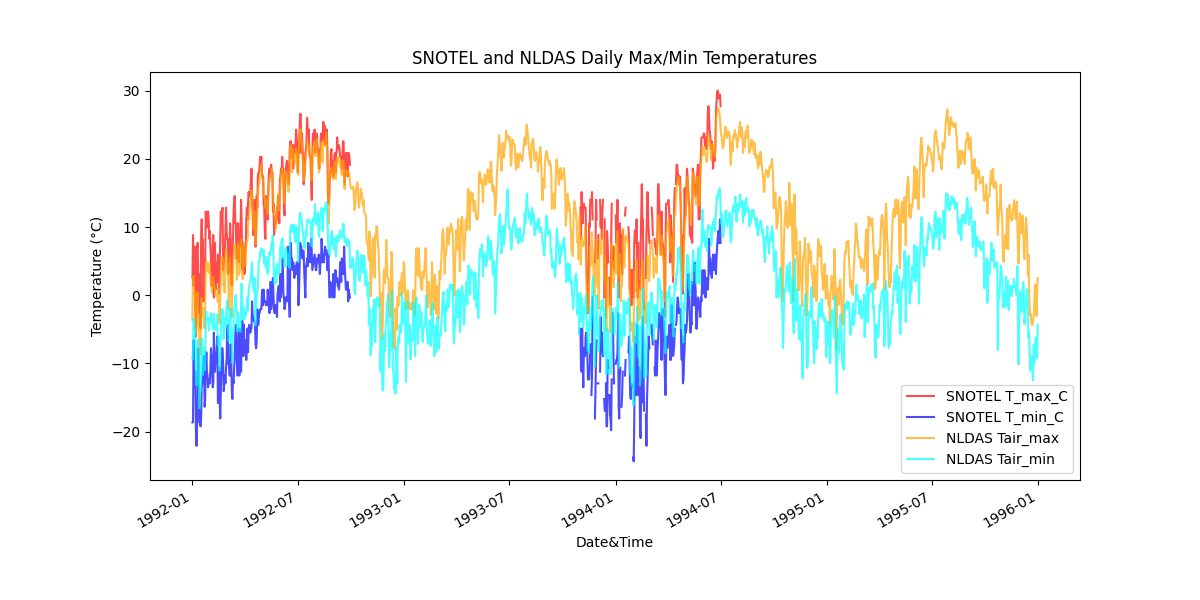

In [43]:
# Plot NLDAS max and min temperatures with SNOTEL data
fig, ax = plt.subplots(figsize=(12, 6))
test_clean['T_max_C'].plot(ax=ax, label='SNOTEL T_max_C', color='red', alpha=0.7)
test_clean['T_min_C'].plot(ax=ax, label='SNOTEL T_min_C', color='blue', alpha=0.7)
nldas_daily['Tair_max'].plot(ax=ax, label='NLDAS Tair_max', color='orange', alpha=0.7)
nldas_daily['Tair_min'].plot(ax=ax, label='NLDAS Tair_min', color='cyan', alpha=0.7)
ax.set_ylabel('Temperature (°C)')
ax.set_title('SNOTEL and NLDAS Daily Max/Min Temperatures')
ax.legend()

It appears that an average shift in the NLDAS data will fill gaps reasonably well.